```text
Calibration analysis
├── Import & Setup
├── Comparing calibration windows
├── Comparing calibration methods
├── Selection
└── W&B Integration
```

# Calibration analysis

#### Import & Setup 

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.decisioning import compare_calibration_methods, compare_calibration_windows
from src.feature_engineering import create_target_def12
from src.plots import plot_calibration_comparison
from src.preprocessing import input_load, time_split
from src.validation import calibration_selector
from src.utils import log_to_wandb

# Dataset specific settings

from src import settings

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas")

In [3]:
# pipeline import

import joblib
pipeline_no_cali = joblib.load("../models/PIPELINE_PD_ver_012_LR_cal_none.pkl")
pipeline_sh_cali = joblib.load("../models/PIPELINE_PD_ver_012.pkl")

In [4]:
# load input file

this_dataset = input_load(2016, 2021)

In [5]:
# CREATE TARGET VARIABLE

this_dataset, dr_summary = create_target_def12(this_dataset)

In [6]:
# SPLIT TRAIN/TEST/OOT

windows = {"oot":  (2021, 2021)}

splits = time_split(this_dataset, settings.COLUMN_YEAR, windows)

X_oot = splits["oot"]["X"]
y_oot = splits["oot"]["y"]

# SPLIT CALIBRATION WINDOWS: 5years/2years/1year

windows = {"lon": (2016, 2020), "mid":  (2019, 2020), "sho":  (2020, 2020)}

splits = time_split(this_dataset, settings.COLUMN_YEAR, windows)

X_2016_2020 = splits["lon"]["X"]
y_2016_2020 = splits["lon"]["y"]
X_2019_2020 = splits["mid"]["X"]
y_2019_2020 = splits["mid"]["y"]
X_2020_2020 = splits["sho"]["X"]
y_2020_2020 = splits["sho"]["y"]


SPLIT SUMMARY

OOT
Years        : 2021 - 2021
Shape (X, y) : (30266, 113), (30266,)

Year distribution
Year
2021    30266
Name: count, dtype: int64

Default rate : 0.1221
------------------------------------------------------------

SPLIT SUMMARY

LON
Years        : 2016 - 2020
Shape (X, y) : (82524, 113), (82524,)

Year distribution
Year
2016     6023
2017    11109
2018    16946
2019    28487
2020    19959
Name: count, dtype: int64

Default rate : 0.1668
------------------------------------------------------------

MID
Years        : 2019 - 2020
Shape (X, y) : (48446, 113), (48446,)

Year distribution
Year
2019    28487
2020    19959
Name: count, dtype: int64

Default rate : 0.1481
------------------------------------------------------------

SHO
Years        : 2020 - 2020
Shape (X, y) : (19959, 113), (19959,)

Year distribution
Year
2020    19959
Name: count, dtype: int64

Default rate : 0.1149
------------------------------------------------------------


## Comparing calibration windows

#### runs 

In [7]:
# LOOP ON VARIOUS CALIBRATION WINDOWS
# ----------------------------------------------------------
# each loop-step trains calibration on a predefined window
# and predicts/calibrates the oot sample 
# ----------------------------------------------------------
# calibration method: 'intercept_shift_test' "shift"  
#    2020-2020 Intercept shift (delta): -0.6810755371595716  
#    2019-2020 Intercept shift (delta): -0.38330530029264454
#    2016-2020 Intercept shift (delta): -0.21698419702798066

## setup calibration windows
windows = {
    "calibrated: on 1yrs, shift": {
        "X": X_2020_2020,
        "y": y_2020_2020,
    },
    "calibrated: on 2yrs, shift": {
        "X": X_2019_2020,
        "y": y_2019_2020,
    },
    "calibrated: on 5yrs, shift": {
        "X": X_2016_2020,
        "y": y_2016_2020,
    },
}

results = compare_calibration_windows(X_oot, y_oot, windows, pipeline_no_cali, show_cali_plots=False)


Run name: calibrated: on 1yrs, shift
----------------------------------------
applying pipeline...
----------------------------------------
training calibration...
Intercept shift (delta): -0.681076
----------------------------------------
BEFORE CALIBRATION
----------------------------------------
----------------------------------------
applying pipeline...
----------------------------------------
calibrating sample...
----------------------------------------
AFTER CALIBRATION
----------------------------------------
Run name: calibrated: on 2yrs, shift
----------------------------------------
applying pipeline...
----------------------------------------
training calibration...
Intercept shift (delta): -0.383305
----------------------------------------
BEFORE CALIBRATION
----------------------------------------
----------------------------------------
applying pipeline...
----------------------------------------
calibrating sample...
----------------------------------------
AFTER CAL

#### metrics comparison

In [8]:
# comparison of basic metrics

results_all_w = pd.DataFrame([
    results["calibrated: on 1yrs, shift"]["metrics_after"],
    results["calibrated: on 2yrs, shift"]["metrics_after"],
    results["calibrated: on 5yrs, shift"]["metrics_after"]
])
display(results_all_w.style.hide(axis="index"))

Dataset,AUC,KS,Observed_DR,Mean_PD,Brier,Exposure,EL_Total,EL_Rate
"OOT (calibrated: on 1yrs, shift)",0.681449,0.259812,0.122051,0.122246,0.101923,85557401.031400,6609819.995185,0.077256
"OOT (calibrated: on 2yrs, shift)",0.681449,0.259812,0.122051,0.156380,0.102991,85557401.031400,8394183.023960,0.098112
"OOT (calibrated: on 5yrs, shift)",0.681449,0.259812,0.122051,0.178499,0.105088,85557401.031400,9538349.020827,0.111485


#### plot

prob_bin,Count,Defaults,Avg_PD_1,Avg_PD_2,Avg_PD_3,Observed_Default_Rate,CI_std,CI_lower,CI_upper,Share_of_Portfolio
"(0.0, 0.05]",46,0,0.022786,0.030446,0.035756,0.000000,0.000000,0.000000,0.000000,0.001520
"(0.05, 0.1]",1775,35,0.044104,0.058486,0.068329,0.019718,0.003300,0.013250,0.026186,0.058647
"(0.1, 0.15]",6509,377,0.068956,0.090676,0.105333,0.057920,0.002895,0.052245,0.063595,0.215060
"(0.15, 0.2]",7962,737,0.096661,0.125933,0.145384,0.092565,0.003248,0.086199,0.098931,0.263067
"(0.2, 0.25]",5882,788,0.127088,0.163908,0.187967,0.133968,0.004441,0.125263,0.142673,0.194343
"(0.25, 0.3]",3501,606,0.159447,0.203459,0.231716,0.173093,0.006394,0.160561,0.185626,0.115674
"(0.3, 0.35]",2001,402,0.194668,0.245564,0.277634,0.200900,0.008957,0.183344,0.218455,0.066114
"(0.35, 0.4]",1166,283,0.230871,0.287850,0.323078,0.242710,0.012555,0.218102,0.267318,0.038525
"(0.4, 0.5]",1103,326,0.285870,0.350095,0.388692,0.295558,0.013739,0.268629,0.322486,0.036444
"(0.5, 0.6]",279,118,0.367685,0.438994,0.480157,0.422939,0.029577,0.364969,0.480909,0.009218


----------------------------------------


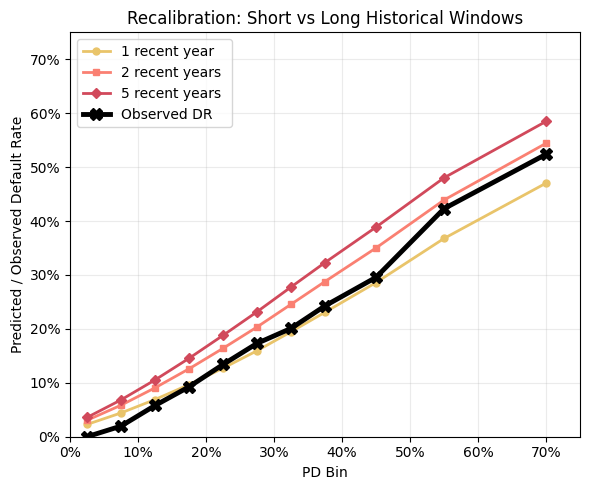

In [9]:
# compare the 3 calibrations on raw pds

plot_calibration_comparison(y_oot,
                          results["calibrated: on 1yrs, shift"]["predictions"]["PD_raw"],
                          results["calibrated: on 1yrs, shift"]["predictions"]["PD"], 
                          results["calibrated: on 2yrs, shift"]["predictions"]["PD"], 
                          results["calibrated: on 5yrs, shift"]["predictions"]["PD"],
                          "1 recent year ",
                          "2 recent years",
                          "5 recent years",
                          "Recalibration: Short vs Long Historical Windows",
                          )

## Comparing calibration methods

#### runs

In [10]:
# LOOP ON VARIOUS CALIBRATION METHODS
# ----------------------------------------------------------
# each loop-step trains calibration on a predefined method
# and predicts/calibrates the oot sample 
# ----------------------------------------------------------
# calibration window: 2019-2020  
#    "shift"    : delta = -0.21698419702798066
#    "platt"    : ...
#    "isotonic" : ...

## setup calibration runs
runs = {
    "calibrated: on 2yrs, shift": {
        "X": X_2019_2020,
        "y": y_2019_2020,
        "method": "shift",
    },
    "calibrated: on 2yrs, platt": {
        "X": X_2019_2020,
        "y": y_2019_2020,
        "method": "platt",    
    },
    "calibrated: on 2yrs, isotonic": {
        "X": X_2019_2020,
        "y": y_2019_2020,
        "method": "isotonic",    
    },
}

results = compare_calibration_methods(X_oot, y_oot, runs, pipeline_no_cali, show_cali_plots=False)

Run name: calibrated: on 2yrs, shift
----------------------------------------
applying pipeline...
----------------------------------------
training calibration...
Intercept shift (delta): -0.383305
----------------------------------------
BEFORE CALIBRATION
----------------------------------------
----------------------------------------
applying pipeline...
----------------------------------------
calibrating sample...
----------------------------------------
AFTER CALIBRATION
----------------------------------------
Run name: calibrated: on 2yrs, platt
----------------------------------------
applying pipeline...
----------------------------------------
training calibration...
----------------------------------------
BEFORE CALIBRATION
----------------------------------------
----------------------------------------
applying pipeline...
----------------------------------------
calibrating sample...
----------------------------------------
AFTER CALIBRATION
--------------------------

#### metrics comparison

In [11]:
# comparison of basic metrics

results_all_m = pd.DataFrame([
    results["calibrated: on 2yrs, shift"]["metrics_after"],
    results["calibrated: on 2yrs, platt"]["metrics_after"],
    results["calibrated: on 2yrs, isotonic"]["metrics_after"]
])
display(results_all_m.style.hide(axis="index"))

Dataset,AUC,KS,Observed_DR,Mean_PD,Brier,Exposure,EL_Total,EL_Rate
"OOT (calibrated: on 2yrs, shift)",0.681449,0.259812,0.122051,0.156380,0.102991,85557401.031400,8394183.023960,0.098112
"OOT (calibrated: on 2yrs, platt)",0.681449,0.259812,0.122051,0.155644,0.103224,85557401.031400,8416730.804179,0.098375
"OOT (calibrated: on 2yrs, isotonic)",0.681314,0.259081,0.122051,0.153994,0.103007,85557401.031400,8311706.807973,0.097148


#### plot

prob_bin,Count,Defaults,Avg_PD_1,Avg_PD_2,Avg_PD_3,Observed_Default_Rate,CI_std,CI_lower,CI_upper,Share_of_Portfolio
"(0.0, 0.05]",46,0,0.059896,0.030446,0.001242,0.000000,0.000000,0.000000,0.000000,0.001520
"(0.05, 0.1]",1775,35,0.074256,0.058486,0.052316,0.019718,0.003300,0.013250,0.026186,0.058647
"(0.1, 0.15]",6509,377,0.093865,0.090676,0.082457,0.057920,0.002895,0.052245,0.063595,0.215060
"(0.15, 0.2]",7962,737,0.119623,0.125933,0.120527,0.092565,0.003248,0.086199,0.098931,0.263067
"(0.2, 0.25]",5882,788,0.152750,0.163908,0.166266,0.133968,0.004441,0.125263,0.142673,0.194343
"(0.25, 0.3]",3501,606,0.193350,0.203459,0.214680,0.173093,0.006394,0.160561,0.185626,0.115674
"(0.3, 0.35]",2001,402,0.243111,0.245564,0.258987,0.200900,0.008957,0.183344,0.218455,0.066114
"(0.35, 0.4]",1166,283,0.299012,0.287850,0.288115,0.242710,0.012555,0.218102,0.267318,0.038525
"(0.4, 0.5]",1103,326,0.389074,0.350095,0.319424,0.295558,0.013739,0.268629,0.322486,0.036444
"(0.5, 0.6]",279,118,0.520990,0.438994,0.391384,0.422939,0.029577,0.364969,0.480909,0.009218


----------------------------------------


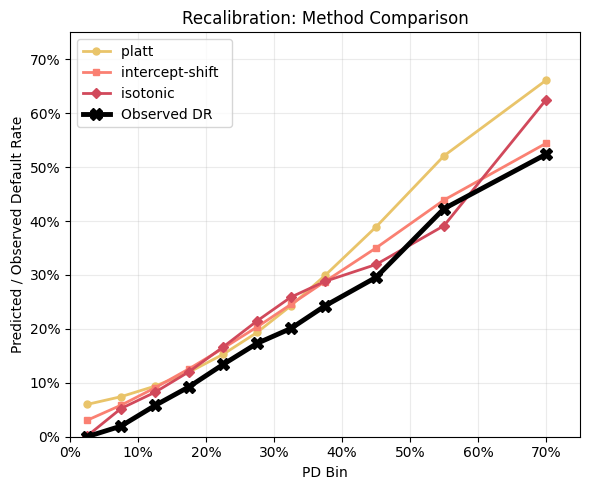

In [12]:
# compare the 3 calibrations on raw pds

plot_calibration_comparison(y_oot,
                          results["calibrated: on 2yrs, platt"]["predictions"]["PD_raw"],
                          results["calibrated: on 2yrs, platt"]["predictions"]["PD"], 
                          results["calibrated: on 2yrs, shift"]["predictions"]["PD"], 
                          results["calibrated: on 2yrs, isotonic"]["predictions"]["PD"],
                          "platt ",
                          "intercept-shift ",
                          "isotonic        ",
                          "Recalibration: Method Comparison"
                          )

## Selection

In [13]:
results_all = pd.concat(
    [results_all_w, results_all_m],
    ignore_index=True
)

display(
    results_all.style
    .hide(axis="index")
    .set_properties(
        subset=[results_all.columns[0]],
        **{"text-align": "left"}
    )
)

_, best_model = calibration_selector(results_all, 'Brier')
best_model

Dataset,AUC,KS,Observed_DR,Mean_PD,Brier,Exposure,EL_Total,EL_Rate
"OOT (calibrated: on 1yrs, shift)",0.681449,0.259812,0.122051,0.122246,0.101923,85557401.031400,6609819.995185,0.077256
"OOT (calibrated: on 2yrs, shift)",0.681449,0.259812,0.122051,0.156380,0.102991,85557401.031400,8394183.023960,0.098112
"OOT (calibrated: on 5yrs, shift)",0.681449,0.259812,0.122051,0.178499,0.105088,85557401.031400,9538349.020827,0.111485
"OOT (calibrated: on 2yrs, shift)",0.681449,0.259812,0.122051,0.156380,0.102991,85557401.031400,8394183.023960,0.098112
"OOT (calibrated: on 2yrs, platt)",0.681449,0.259812,0.122051,0.155644,0.103224,85557401.031400,8416730.804179,0.098375
"OOT (calibrated: on 2yrs, isotonic)",0.681314,0.259081,0.122051,0.153994,0.103007,85557401.031400,8311706.807973,0.097148


,Dataset,AUC,KS,Observed_DR,Mean_PD,Brier,Exposure,EL_Total,EL_Rate
0,"OOT (calibrated: on 1yrs, shift)",0.681449,0.259812,0.122051,0.122246,0.101923,8.555740e+07,6.609820e+06,0.077256


## W&B integration

In [14]:
# log to W&B

# log_to_wandb(
#     metrics=metrics_xxx,
#     calibration="xxx",
#     window="2016-2020",
#     cal_plot=cal_plot_xxx
# )